In [1]:
! pip install ray

In [2]:
# 주의! ray를 pytorch보다 먼저 import하면 오류가 발생할 수 있습니다
import io, json, os, math

import torch
import torch.nn as nn
import torch.nn.functional as F

import ray

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# 프로젝트 경로 설정
PROJECT_PATH = os.path.join(os.getenv("HOME"), 'work/mpii')
IMAGE_PATH = os.path.join(PROJECT_PATH, 'images')
MODEL_PATH = os.path.join(PROJECT_PATH, 'models')
PT_RECORD_PATH = os.path.join(PROJECT_PATH, 'ptrecords_mpii')
TRAIN_JSON = os.path.join(PROJECT_PATH, 'mpii_human_pose_v1_u12_2', 'train.json')
VALID_JSON = os.path.join(PROJECT_PATH, 'mpii_human_pose_v1_u12_2', 'validation.json')

print('슝=3')

슝=3


In [3]:
with open(TRAIN_JSON) as train_json:
    train_annos = json.load(train_json)
    json_formatted_str = json.dumps(train_annos[0], indent=2)
    print(json_formatted_str)

{
  "joints_vis": [
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1
  ],
  "joints": [
    [
      620.0,
      394.0
    ],
    [
      616.0,
      269.0
    ],
    [
      573.0,
      185.0
    ],
    [
      647.0,
      188.0
    ],
    [
      661.0,
      221.0
    ],
    [
      656.0,
      231.0
    ],
    [
      610.0,
      187.0
    ],
    [
      647.0,
      176.0
    ],
    [
      637.0201,
      189.8183
    ],
    [
      695.9799,
      108.1817
    ],
    [
      606.0,
      217.0
    ],
    [
      553.0,
      161.0
    ],
    [
      601.0,
      167.0
    ],
    [
      692.0,
      185.0
    ],
    [
      693.0,
      240.0
    ],
    [
      688.0,
      313.0
    ]
  ],
  "image": "015601864.jpg",
  "scale": 3.021046,
  "center": [
    594.0,
    257.0
  ]
}


In [4]:
def parse_one_annotation(anno, image_dir):
    filename = anno['image']
    joints = anno['joints']
    joints_visibility = anno['joints_vis']
    annotation = {
        'filename': filename,
        'filepath': os.path.join(image_dir, filename),
        'joints_visibility': joints_visibility,
        'joints': joints,
        'center': anno['center'],
        'scale' : anno['scale']
    }
    return annotation

print('슝=3')

슝=3


In [5]:
with open(TRAIN_JSON) as train_json:
    train_annos = json.load(train_json)
    test = parse_one_annotation(train_annos[0], IMAGE_PATH)
    print(test)

{'filename': '015601864.jpg', 'filepath': '/home/jovyan/work/mpii/images/015601864.jpg', 'joints_visibility': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'joints': [[620.0, 394.0], [616.0, 269.0], [573.0, 185.0], [647.0, 188.0], [661.0, 221.0], [656.0, 231.0], [610.0, 187.0], [647.0, 176.0], [637.0201, 189.8183], [695.9799, 108.1817], [606.0, 217.0], [553.0, 161.0], [601.0, 167.0], [692.0, 185.0], [693.0, 240.0], [688.0, 313.0]], 'center': [594.0, 257.0], 'scale': 3.021046}


In [6]:
def generate_ptexample(anno):
    filename = anno['filename']
    filepath = anno['filepath']

    # 이미지 파일 읽기
    with open(filepath, 'rb') as image_file:
        content = image_file.read()

    image = Image.open(filepath)
    # JPEG 형식 및 RGB 모드가 아니면 변환
    if image.format != 'JPEG' or image.mode != 'RGB':
        image_rgb = image.convert('RGB')
        with io.BytesIO() as output:
            image_rgb.save(output, format="JPEG", quality=95)
            content = output.getvalue()

    width, height = image.size
    depth = 3

    c_x = int(anno['center'][0])
    c_y = int(anno['center'][1])
    scale = anno['scale']

    x = [int(joint[0]) if joint[0] >= 0 else int(joint[0])
         for joint in anno['joints']]
    y = [int(joint[1]) if joint[1] >= 0 else int(joint[0])
         for joint in anno['joints']]

    v = [0 if joint_v == 0 else 2 for joint_v in anno['joints_visibility']]

    feature = {
        'image/height': height,
        'image/width': width,
        'image/depth': depth,
        'image/object/parts/x': x,
        'image/object/parts/y': y,
        'image/object/center/x': c_x,
        'image/object/center/y': c_y,
        'image/object/scale': scale,
        'image/object/parts/v': v,
        'image/encoded': content,
        'image/filename': filename.encode()  # bytes로 저장
    }

    return feature

print('슝=3')

슝=3


In [7]:
def chunkify(l, n):
    size = len(l) // n
    start = 0
    results = []
    for i in range(n):
        results.append(l[start:start + size])
        start += size
    return results

print('슝=3')

슝=3


In [8]:
test_chunks = chunkify([0] * 1000, 64)
print(test_chunks)
print(len(test_chunks))
print(len(test_chunks[0]))

[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0,

In [9]:
import pickle

@ray.remote
def build_single_ptrecord(chunk, path):
    print('start to build ptrecord for ' + path)

    with open(path, 'wb') as writer:
        for anno in chunk:
            ptexample = generate_ptexample(anno)
            pickle.dump(ptexample, writer)

    print('finished building ptrecord for ' + path)

print('슝=3')

슝=3


In [10]:
def build_pt_records(annotations, total_shards, split):
    chunks = chunkify(annotations, total_shards)
    futures = [
        build_single_ptrecord.remote(
            chunk, '{}/{}_{}_of_{}.ptrecords'.format(
                PT_RECORD_PATH,
                split,
                str(i + 1).zfill(4),
                str(total_shards).zfill(4),
            )
        ) for i, chunk in enumerate(chunks)
    ]
    ray.get(futures)

print('슝=3')

슝=3


In [11]:
from torch.utils.data import Dataset

class MPIIDataset(Dataset):
    def __init__(self, annotation_file, image_dir, transform=None):
        self.image_dir = image_dir
        self.transform = transform

        # JSON 파일을 읽어 annotations 리스트 생성
        with open(annotation_file, 'r') as f:
            annotations = json.load(f)

        # 각 annotation을 파싱하여 리스트에 저장
        self.annotations = [parse_one_annotation(anno, image_dir) for anno in annotations]

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
        anno = self.annotations[idx]
        # 이미지 파일 경로로부터 이미지를 로드 (RGB 모드로 변환)
        image = Image.open(anno['filepath']).convert('RGB')

        # transform이 있으면 적용
        if self.transform:
            image, heatmaps = self.transform({'image': image, 'annotation': anno})
            return image, heatmaps
        else:
            # transform이 없으면 원본 이미지와 annotation dict 반환
            return image, anno

In [12]:
import ray

# 기존 세션이 있다면 종료
if ray.is_initialized():
    ray.shutdown()

ray.init()

2026-03-03 18:14:07,797	WARNING services.py:2168 -- WARNING: The object store is using /tmp instead of /dev/shm because /dev/shm has only 67108864 bytes available. This will harm performance! You may be able to free up space by deleting files in /dev/shm. If you are inside a Docker container, you can increase /dev/shm size by passing '--shm-size=5.04gb' to 'docker run' (or add it to the run_options list in a Ray cluster config). Make sure to set this to more than 30% of available RAM.
2026-03-03 18:14:09,961	INFO worker.py:2013 -- Started a local Ray instance.
/opt/conda/lib/python3.12/site-packages/ray/_private/worker.py:2052: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


Python version:,3.12.11
Ray version:,2.54.0


(build_single_ptrecord pid=1224) start to build ptrecord for /home/jovyan/work/mpii/ptrecords_mpii/train_0001_of_0064.ptrecords
(build_single_ptrecord pid=1222) finished building ptrecord for /home/jovyan/work/mpii/ptrecords_mpii/train_0003_of_0064.ptrecords
(build_single_ptrecord pid=1224) start to build ptrecord for /home/jovyan/work/mpii/ptrecords_mpii/train_0006_of_0064.ptrecords [repeated 5x across cluster] (Ray deduplicates logs by default. Set RAY_DEDUP_LOGS=0 to disable log deduplication, or see https://docs.ray.io/en/master/ray-observability/user-guides/configure-logging.html#log-deduplication for more options.)
(build_single_ptrecord pid=1224) finished building ptrecord for /home/jovyan/work/mpii/ptrecords_mpii/train_0008_of_0064.ptrecords [repeated 6x across cluster]
(build_single_ptrecord pid=1224) start to build ptrecord for /home/jovyan/work/mpii/ptrecords_mpii/train_0013_of_0064.ptrecords [repeated 7x across cluster]
(build_single_ptrecord pid=1224) finished building ptr

In [13]:
ray.init(ignore_reinit_error=True)

2026-03-03 18:14:11,059	INFO worker.py:1831 -- Calling ray.init() again after it has already been called.


Python version:,3.12.11
Ray version:,2.54.0


In [14]:
%%time
num_train_shards = 64
num_val_shards = 8

print('Start to parse annotations.')
if not os.path.exists(PT_RECORD_PATH):
    os.makedirs(PT_RECORD_PATH)

with open(TRAIN_JSON) as train_json:
    train_annos = json.load(train_json)
    train_annotations = [
        parse_one_annotation(anno, IMAGE_PATH)
        for anno in train_annos
    ]
    print('First train annotation: ', train_annotations[0])

with open(VALID_JSON) as val_json:
    val_annos = json.load(val_json)
    val_annotations = [
        parse_one_annotation(anno, IMAGE_PATH)
        for anno in val_annos
    ]
    print('First val annotation: ', val_annotations[0])

print('Start to build PT Records.')
build_pt_records(train_annotations, num_train_shards, 'train')
build_pt_records(val_annotations, num_val_shards, 'val')

print('Successfully wrote {} annotations to PT Records.'.format(
    len(train_annotations) + len(val_annotations)))

Start to parse annotations.
First train annotation:  {'filename': '015601864.jpg', 'filepath': '/home/jovyan/work/mpii/images/015601864.jpg', 'joints_visibility': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'joints': [[620.0, 394.0], [616.0, 269.0], [573.0, 185.0], [647.0, 188.0], [661.0, 221.0], [656.0, 231.0], [610.0, 187.0], [647.0, 176.0], [637.0201, 189.8183], [695.9799, 108.1817], [606.0, 217.0], [553.0, 161.0], [601.0, 167.0], [692.0, 185.0], [693.0, 240.0], [688.0, 313.0]], 'center': [594.0, 257.0], 'scale': 3.021046}
First val annotation:  {'filename': '005808361.jpg', 'filepath': '/home/jovyan/work/mpii/images/005808361.jpg', 'joints_visibility': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'joints': [[804.0, 711.0], [816.0, 510.0], [908.0, 438.0], [1040.0, 454.0], [906.0, 528.0], [883.0, 707.0], [974.0, 446.0], [985.0, 253.0], [982.7591, 235.9694], [962.2409, 80.0306], [869.0, 214.0], [798.0, 340.0], [902.0, 253.0], [1067.0, 253.0], [1167.0, 353.0], [1142.0, 478.0

In [15]:
!pip install tfrecord

In [16]:
from tfrecord.torch.dataset import TFRecordDataset

feature_description = {
    'image/height': 'int',
    'image/width': 'int',
    'image/depth': 'int',
    'image/object/parts/x': 'int',
    'image/object/parts/y': 'int',
    'image/object/parts/v': 'int',
    'image/object/center/x': 'int',
    'image/object/center/y': 'int',
    'image/object/scale': 'float',
    'image/encoded': 'byte',
    'image/filename': 'byte',
}

print('슝=3')

슝=3


In [17]:
import torch

def crop_roi(image, features, margin=0.2):
    img_height, img_width, img_depth = image.shape

    keypoint_x = torch.tensor(features['image/object/parts/x'], dtype=torch.int32)
    keypoint_y = torch.tensor(features['image/object/parts/y'], dtype=torch.int32)
    center_x = features['image/object/center/x']
    center_y = features['image/object/center/y']
    body_height = features['image/object/scale'] * 200.0

    # 유효한 keypoint (값이 0보다 큰 값)만 선택합니다.
    masked_keypoint_x = keypoint_x[keypoint_x > 0]
    masked_keypoint_y = keypoint_y[keypoint_y > 0]

    # 최소, 최대 값 계산 (유효한 keypoint가 하나 이상 있다고 가정)
    keypoint_xmin = masked_keypoint_x.min()
    keypoint_xmax = masked_keypoint_x.max()
    keypoint_ymin = masked_keypoint_y.min()
    keypoint_ymax = masked_keypoint_y.max()

    # margin을 적용하여 경계를 확장 (body_height * margin 값을 정수로 캐스팅)
    extra = int(body_height * margin)
    xmin = int(keypoint_xmin.item()) - extra
    xmax = int(keypoint_xmax.item()) + extra
    ymin = int(keypoint_ymin.item()) - extra
    ymax = int(keypoint_ymax.item()) + extra

    # 이미지 경계를 벗어나지 않도록 조정
    effective_xmin = xmin if xmin > 0 else 0
    effective_ymin = ymin if ymin > 0 else 0
    effective_xmax = xmax if xmax < img_width else img_width
    effective_ymax = ymax if ymax < img_height else img_height

    # 이미지 크기 재조정
    cropped_image = image[effective_ymin:effective_ymax, effective_xmin:effective_xmax, :]
    new_height, new_width, _ = cropped_image.shape

    # keypoint 좌표를 정규화 (0~1 범위)
    effective_keypoint_x = (keypoint_x.float() - effective_xmin) / new_width
    effective_keypoint_y = (keypoint_y.float() - effective_ymin) / new_height

    return cropped_image, effective_keypoint_x, effective_keypoint_y

print('슝=3')

슝=3


In [18]:
import torch

def generate_2d_gaussian(height, width, y0, x0, visibility=2, sigma=1, scale=12):
    # (height, width) 크기의 0으로 채워진 heatmap 생성
    heatmap = torch.zeros((height, width), dtype=torch.float32)

    xmin = x0 - 3 * sigma
    ymin = y0 - 3 * sigma
    xmax = x0 + 3 * sigma
    ymax = y0 + 3 * sigma

    # 범위가 이미지 내에 없거나, visibility가 0이면 heatmap 그대로 반환
    if xmin >= width or ymin >= height or xmax < 0 or ymax < 0 or visibility == 0:
        return heatmap

    size = int(6 * sigma + 1)
    grid_range = torch.arange(0, size, dtype=torch.float32)
    x_grid, y_grid = torch.meshgrid(grid_range, grid_range, indexing='xy')
    center_x = size // 2
    center_y = size // 2

    # 가우시안 patch 계산
    gaussian_patch = torch.exp(-(((x_grid - center_x)**2 + (y_grid - center_y)**2) / (sigma**2 * 2))) * scale

    # 이미지와 patch 간의 겹치는 영역 계산
    patch_xmin = max(0, -xmin)
    patch_ymin = max(0, -ymin)
    patch_xmax = min(xmax, width) - xmin
    patch_ymax = min(ymax, height) - ymin

    heatmap_xmin = max(0, xmin)
    heatmap_ymin = max(0, ymin)
    heatmap_xmax = min(xmax, width)
    heatmap_ymax = min(ymax, height)

    # 계산된 영역에 gaussian_patch 값을 할당
    heatmap[heatmap_ymin:heatmap_ymax, heatmap_xmin:heatmap_xmax] = \
        gaussian_patch[int(patch_ymin):int(patch_ymax), int(patch_xmin):int(patch_xmax)]

    return heatmap

def make_heatmaps(features, keypoint_x, keypoint_y, heatmap_shape):
    v = torch.tensor(features['image/object/parts/v'], dtype=torch.float32)
    x = torch.round(torch.tensor(keypoint_x, dtype=torch.float32) * heatmap_shape[0]).to(torch.int32)
    y = torch.round(torch.tensor(keypoint_y, dtype=torch.float32) * heatmap_shape[1]).to(torch.int32)

    num_heatmap = heatmap_shape[2]
    heatmaps_list = []
    for i in range(num_heatmap):
        # generate_2d_gaussian 함수 호출 시, height=heatmap_shape[1], width=heatmap_shape[0]
        gaussian = generate_2d_gaussian(
            heatmap_shape[1],
            heatmap_shape[0],
            int(y[i].item()),
            int(x[i].item()),
            visibility=int(v[i].item())
        )
        heatmaps_list.append(gaussian)

    # (num_heatmap, height, width) 텐서를 생성한 후, (height, width, num_heatmap)로 전치
    heatmaps = torch.stack(heatmaps_list, dim=0)
    heatmaps = heatmaps.permute(1, 2, 0)

    return heatmaps

print('슝=3')

슝=3


In [19]:
import torch
from PIL import Image
import io
import numpy as np

class Preprocessor(object):
    def __init__(self,
                 image_shape=(256, 256, 3),
                 heatmap_shape=(64, 64, 16),
                 is_train=False):
        self.is_train = is_train
        self.image_shape = image_shape      # (height, width, channels)
        self.heatmap_shape = heatmap_shape  # (height, width, num_heatmap)

    def __call__(self, example):
        features = self.parse_tfexample(example)
        # image 데이터를 다시 bytes로 디코딩 후 재로딩 (JPEG 형식)
        image = Image.open(io.BytesIO(features['image/encoded']))

        if self.is_train:
            # 0.1 ~ 0.3 사이의 random margin 생성
            random_margin = torch.empty(1).uniform_(0.1, 0.3).item()
            image, keypoint_x, keypoint_y = self.crop_roi(image, features, margin=random_margin)
            image = image.resize((self.image_shape[1], self.image_shape[0]))
        else:
            image, keypoint_x, keypoint_y = self.crop_roi(image, features)
            image = image.resize((self.image_shape[1], self.image_shape[0]))

        # 이미지 정규화: uint8 → [0,255] → [-1, 1]
        image_np = np.array(image).astype(np.float32)
        image_np = image_np / 127.5 - 1.0
        # 채널 우선순서로 변환: (H, W, C) -> (C, H, W)
        image_tensor = torch.from_numpy(image_np).permute(2, 0, 1)

        heatmaps = self.make_heatmaps(features, keypoint_x, keypoint_y, self.heatmap_shape)

        return image_tensor, heatmaps

    def parse_tfexample(self, example):
        """
        MPIIDataset에서 전달한 예제를 받아, Preprocessor가 처리할 수 있도록 features dict를 구성합니다.
        예제 형식: {'image': PIL.Image, 'annotation': anno}
        """
        annotation = example['annotation']
        # joints: list of [x, y]
        joints = annotation['joints']
        keypoint_x = [joint[0] for joint in joints]
        keypoint_y = [joint[1] for joint in joints]

        # joints_vis가 없으면 모든 관절이 가시적이라고 가정 (1)
        joints_vis = annotation.get('joints_vis', [1] * len(joints))

        features = {
            'image/encoded': self.image_to_bytes(example['image']),
            'image/object/parts/x': keypoint_x,
            'image/object/parts/y': keypoint_y,
            'image/object/parts/v': joints_vis,
            'image/object/center/x': annotation['center'][0],
            'image/object/center/y': annotation['center'][1],
            'image/object/scale': annotation['scale'],
        }
        return features

    def image_to_bytes(self, image):
        """
        PIL.Image 객체를 JPEG 인코딩된 bytes로 변환합니다.
        """
        buffer = io.BytesIO()
        image.save(buffer, format="JPEG")
        return buffer.getvalue()

    def crop_roi(self, image, features, margin=0.2):
        # image: PIL.Image, features: dict
        img_width, img_height = image.size  # PIL: (width, height)

        keypoint_x = torch.tensor(features['image/object/parts/x'], dtype=torch.int32)
        keypoint_y = torch.tensor(features['image/object/parts/y'], dtype=torch.int32)
        body_height = features['image/object/scale'] * 200.0

        # 유효한 keypoint (값 > 0)만 선택
        masked_keypoint_x = keypoint_x[keypoint_x > 0]
        masked_keypoint_y = keypoint_y[keypoint_y > 0]

        keypoint_xmin = int(masked_keypoint_x.min().item())
        keypoint_xmax = int(masked_keypoint_x.max().item())
        keypoint_ymin = int(masked_keypoint_y.min().item())
        keypoint_ymax = int(masked_keypoint_y.max().item())

        extra = int(body_height * margin)
        xmin = keypoint_xmin - extra
        xmax = keypoint_xmax + extra
        ymin = keypoint_ymin - extra
        ymax = keypoint_ymax + extra

        effective_xmin = max(xmin, 0)
        effective_ymin = max(ymin, 0)
        effective_xmax = min(xmax, img_width)
        effective_ymax = min(ymax, img_height)

        cropped_image = image.crop((effective_xmin, effective_ymin, effective_xmax, effective_ymax))

        new_width = effective_xmax - effective_xmin
        new_height = effective_ymax - effective_ymin

        effective_keypoint_x = (keypoint_x.float() - effective_xmin) / new_width
        effective_keypoint_y = (keypoint_y.float() - effective_ymin) / new_height

        return cropped_image, effective_keypoint_x, effective_keypoint_y

    def generate_2d_guassian(self, height, width, y0, x0, visibility=2, sigma=1, scale=12):
        heatmap = torch.zeros((height, width), dtype=torch.float32)

        xmin = x0 - 3 * sigma
        ymin = y0 - 3 * sigma
        xmax = x0 + 3 * sigma
        ymax = y0 + 3 * sigma

        if xmin >= width or ymin >= height or xmax < 0 or ymax < 0 or visibility == 0:
            return heatmap

        size = int(6 * sigma + 1)
        grid_range = torch.arange(0, size, dtype=torch.float32)
        x_grid, y_grid = torch.meshgrid(grid_range, grid_range, indexing='xy')
        center_x = size // 2
        center_y = size // 2

        gaussian_patch = torch.exp(-(((x_grid - center_x)**2 + (y_grid - center_y)**2) / (2 * sigma**2))) * scale

        patch_xmin = max(0, -xmin)
        patch_ymin = max(0, -ymin)
        patch_xmax = min(xmax, width) - xmin
        patch_ymax = min(ymax, height) - ymin

        heatmap_xmin = max(0, xmin)
        heatmap_ymin = max(0, ymin)
        heatmap_xmax = min(xmax, width)
        heatmap_ymax = min(ymax, height)

        heatmap[heatmap_ymin:heatmap_ymax, heatmap_xmin:heatmap_xmax] = \
            gaussian_patch[int(patch_ymin):int(patch_ymax), int(patch_xmin):int(patch_xmax)]

        return heatmap

    def make_heatmaps(self, features, keypoint_x, keypoint_y, heatmap_shape):
        # heatmap_shape: (height, width, num_heatmap)
        v = torch.tensor(features['image/object/parts/v'], dtype=torch.float32)
        x = torch.round(keypoint_x * heatmap_shape[1]).to(torch.int32)  # width: heatmap_shape[1]
        y = torch.round(keypoint_y * heatmap_shape[0]).to(torch.int32)  # height: heatmap_shape[0]

        num_heatmap = heatmap_shape[2]
        heatmaps_list = []

        for i in range(num_heatmap):
            gaussian = self.generate_2d_guassian(
                height=heatmap_shape[0],
                width=heatmap_shape[1],
                y0=int(y[i].item()),
                x0=int(x[i].item()),
                visibility=int(v[i].item())
            )
            heatmaps_list.append(gaussian)

        # 스택 후, (num_heatmap, height, width) 형태로 반환
        heatmaps = torch.stack(heatmaps_list, dim=0)
        return heatmaps

print('슝=3')

슝=3


In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class BottleneckBlock(nn.Module):
    def __init__(self, in_channels, filters, stride=1, downsample=False):
        super(BottleneckBlock, self).__init__()
        self.downsample = downsample
        # 만약 downsample이라면 identity branch에 1x1 conv 적용하여 채널 수와 spatial size 조정
        if self.downsample:
            self.downsample_conv = nn.Conv2d(in_channels, filters, kernel_size=1, stride=stride, bias=False)

        # main branch
        self.bn1 = nn.BatchNorm2d(in_channels, momentum=0.9)
        self.relu = nn.ReLU(inplace=True)
        self.conv1 = nn.Conv2d(in_channels, filters // 2, kernel_size=1, stride=1, padding=0, bias=False)

        self.bn2 = nn.BatchNorm2d(filters // 2, momentum=0.9)
        # kernel_size=3, padding=1로 'same' padding 효과
        self.conv2 = nn.Conv2d(filters // 2, filters // 2, kernel_size=3, stride=stride, padding=1, bias=False)

        self.bn3 = nn.BatchNorm2d(filters // 2, momentum=0.9)
        self.conv3 = nn.Conv2d(filters // 2, filters, kernel_size=1, stride=1, padding=0, bias=False)

    def forward(self, x):
        identity = x
        if self.downsample:
            identity = self.downsample_conv(x)

        out = self.bn1(x)
        out = self.relu(out)
        out = self.conv1(out)

        out = self.bn2(out)
        out = self.relu(out)
        out = self.conv2(out)

        out = self.bn3(out)
        out = self.relu(out)
        out = self.conv3(out)

        out += identity
        return out

print('슝=3')

슝=3


In [21]:
import torch
import torch.nn as nn

class HourglassModule(nn.Module):
    def __init__(self, order, filters, num_residual):
        super(HourglassModule, self).__init__()
        self.order = order

        # Up branch: BottleneckBlock 1회 + num_residual회 반복
        self.up1_0 = BottleneckBlock(in_channels=filters, filters=filters, stride=1, downsample=False)
        self.up1_blocks = nn.Sequential(*[
            BottleneckBlock(in_channels=filters, filters=filters, stride=1, downsample=False)
            for _ in range(num_residual)
        ])

        # Low branch: MaxPool + num_residual BottleneckBlock
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.low1_blocks = nn.Sequential(*[
            BottleneckBlock(in_channels=filters, filters=filters, stride=1, downsample=False)
            for _ in range(num_residual)
        ])

        # Recursive hourglass or additional BottleneckBlocks
        if order > 1:
            self.low2 = HourglassModule(order - 1, filters, num_residual)
        else:
            self.low2_blocks = nn.Sequential(*[
                BottleneckBlock(in_channels=filters, filters=filters, stride=1, downsample=False)
                for _ in range(num_residual)
            ])

        # 후처리 BottleneckBlock 반복
        self.low3_blocks = nn.Sequential(*[
            BottleneckBlock(in_channels=filters, filters=filters, stride=1, downsample=False)
            for _ in range(num_residual)
        ])

        # UpSampling (최근접 보간법)
        self.upsample = nn.Upsample(scale_factor=2, mode='nearest')

    def forward(self, x):
        # up branch
        up1 = self.up1_0(x)
        up1 = self.up1_blocks(up1)

        # low branch
        low1 = self.pool(x)
        low1 = self.low1_blocks(low1)
        if self.order > 1:
            low2 = self.low2(low1)
        else:
            low2 = self.low2_blocks(low1)
        low3 = self.low3_blocks(low2)
        up2 = self.upsample(low3)

        return up2 + up1

print('슝=3')

슝=3


In [22]:
import torch
import torch.nn as nn

class LinearLayer(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(LinearLayer, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1, padding=0, bias=False)
        self.bn = nn.BatchNorm2d(out_channels, momentum=0.9)
        self.relu = nn.ReLU(inplace=True)

        # He (Kaiming) 초기화 적용
        nn.init.kaiming_normal_(self.conv.weight, mode='fan_out', nonlinearity='relu')

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.relu(x)
        return x

print('슝=3')

슝=3


In [23]:
import torch
import torch.nn as nn

class StackedHourglassNetwork(nn.Module):
    def __init__(self, input_shape=(256, 256, 3), num_stack=4, num_residual=1, num_heatmap=16):
        super(StackedHourglassNetwork, self).__init__()
        self.num_stack = num_stack

        in_channels = input_shape[2]  # 3
        self.conv1 = nn.Conv2d(in_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64, momentum=0.9)
        self.relu = nn.ReLU(inplace=True)

        # Bottleneck blocks 초기화
        # BottleneckBlock의 첫번째 호출: 64 → 128, downsample=True
        self.bottleneck1 = BottleneckBlock(in_channels=64, filters=128, stride=1, downsample=True)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        # 두 번째: 128 → 128, downsample=False
        self.bottleneck2 = BottleneckBlock(in_channels=128, filters=128, stride=1, downsample=False)
        # 세 번째: 128 → 256, downsample=True
        self.bottleneck3 = BottleneckBlock(in_channels=128, filters=256, stride=1, downsample=True)

        # 스택 구성 요소들
        self.hourglass_modules = nn.ModuleList()
        self.residual_modules = nn.ModuleList()  # hourglass 후 residual block들 (num_residual회)
        self.linear_layers = nn.ModuleList()
        self.heatmap_convs = nn.ModuleList()
        # 마지막 스택을 제외한 중간 피쳐 결합용 1x1 conv
        self.intermediate_convs = nn.ModuleList()
        self.intermediate_outs = nn.ModuleList()

        for i in range(num_stack):
            # order=4인 hourglass 모듈 (앞에서 정의한 HourglassModule 사용)
            self.hourglass_modules.append(HourglassModule(order=4, filters=256, num_residual=num_residual))
            # hourglass 후 residual block들
            self.residual_modules.append(nn.Sequential(*[
                BottleneckBlock(in_channels=256, filters=256, stride=1, downsample=False)
                for _ in range(num_residual)
            ]))
            # Linear layer: 1x1 conv + BN + ReLU (앞에서 정의한 LinearLayer 사용)
            self.linear_layers.append(LinearLayer(in_channels=256, out_channels=256))
            # 최종 heatmap을 생성하는 1x1 conv
            self.heatmap_convs.append(nn.Conv2d(256, num_heatmap, kernel_size=1, stride=1, padding=0))

            if i < num_stack - 1:
                self.intermediate_convs.append(nn.Conv2d(256, 256, kernel_size=1, stride=1, padding=0))
                self.intermediate_outs.append(nn.Conv2d(num_heatmap, 256, kernel_size=1, stride=1, padding=0))

    def forward(self, x):
        # x: (B, 3, H, W)
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.bottleneck1(x)
        x = self.pool(x)
        x = self.bottleneck2(x)
        x = self.bottleneck3(x)

        outputs = []
        for i in range(self.num_stack):
            hg = self.hourglass_modules[i](x)
            res = self.residual_modules[i](hg)
            lin = self.linear_layers[i](res)
            heatmap = self.heatmap_convs[i](lin)
            outputs.append(heatmap)

            if i < self.num_stack - 1:
                inter1 = self.intermediate_convs[i](lin)
                inter2 = self.intermediate_outs[i](heatmap)
                x = inter1 + inter2  # 다음 스택의 입력으로 사용

        return outputs

print('슝=3')

슝=3


In [24]:
import os
import math
import torch
import torch.nn as nn
import torch.optim as optim

class Trainer(object):
    def __init__(self,
                 model,
                 epochs,
                 global_batch_size,
                 initial_learning_rate):
        """
        - model: 학습시킬 PyTorch 모델(nn.Module)
        - epochs: 전체 학습 epoch 수
        - global_batch_size: 전체 배치 크기 (loss 계산 시 사용)
        - initial_learning_rate: 초기 학습률
        """
        self.model = model
        self.epochs = epochs
        self.global_batch_size = global_batch_size

        # MSE loss를 reduction='none'으로 사용 (가중치 적용을 위해)
        self.loss_object = nn.MSELoss(reduction='none')

        # Adam optimizer 초기화
        self.optimizer = optim.Adam(self.model.parameters(), lr=initial_learning_rate)

        # 학습률 스케줄링 관련 변수들
        self.current_learning_rate = initial_learning_rate
        self.last_val_loss = math.inf
        self.lowest_val_loss = math.inf
        self.patience_count = 0
        self.max_patience = 10

        # 최적 모델 체크포인트 저장
        self.best_model = None

        # 단일 GPU/멀티 GPU(DataParallel) 설정
        if torch.cuda.device_count() > 1:
            print(f"멀티 GPU 사용 (GPU 개수: {torch.cuda.device_count()})")
            self.model = nn.DataParallel(self.model)
        else:
            print("단일 GPU 혹은 CPU 사용")

    def lr_decay(self):
        """
        patience_count가 max_patience를 넘으면 학습률을 1/10으로 감소,
        그렇지 않고 val_loss가 그대로면 patience_count += 1,
        새 최저 val_loss를 달성하면 patience_count를 0으로.
        """
        if self.patience_count >= self.max_patience:
            self.current_learning_rate /= 10.0
            self.patience_count = 0
        elif self.last_val_loss == self.lowest_val_loss:
            self.patience_count = 0

        self.patience_count += 1

        # optimizer의 learning rate 갱신
        for param_group in self.optimizer.param_groups:
            param_group['lr'] = self.current_learning_rate

    def lr_decay_step(self, epoch):
        """
        25, 50, 75 epoch에서 학습률을 1/10으로 감소시키는 스케줄링.
        """
        if epoch in [25, 50, 75]:
            self.current_learning_rate /= 10.0

        for param_group in self.optimizer.param_groups:
            param_group['lr'] = self.current_learning_rate

    def compute_loss(self, labels, outputs):
        """
        여러 스택의 heatmap 출력(outputs)에 대해 MSE를 구하되,
        labels > 0인 위치에는 81의 추가 가중치를 적용.
        """
        loss = 0
        for output in outputs:
            # labels > 0 이면 81 + 1 = 82, 아니면 1
            weights = (labels > 0).float() * 81 + 1
            squared_error = (labels - output) ** 2
            weighted_error = squared_error * weights
            # 전체 배치에 대한 평균 후, global_batch_size로 나눔
            loss += weighted_error.mean() / self.global_batch_size
        return loss

    def train_step(self, images, labels, device):
        self.model.train()
        images = images.to(device)
        labels = labels.to(device)

        self.optimizer.zero_grad()
        outputs = self.model(images)
        loss = self.compute_loss(labels, outputs)
        loss.backward()
        self.optimizer.step()

        return loss.item()

    def val_step(self, images, labels, device):
        self.model.eval()
        with torch.no_grad():
            images = images.to(device)
            labels = labels.to(device)
            outputs = self.model(images)
            loss = self.compute_loss(labels, outputs)
        return loss.item()

    def run(self, train_loader, val_loader, device):
        """
        - train_loader, val_loader: PyTorch DataLoader
        - device: torch.device('cuda' or 'cpu')
        """
        for epoch in range(1, self.epochs + 1):
            # 학습률 감소 로직
            self.lr_decay()
            print(f"Start epoch {epoch} with learning rate {self.current_learning_rate:.6f}")

            # Training
            total_train_loss = 0.0
            num_train_batches = 0
            for images, labels in train_loader:
                batch_loss = self.train_step(images, labels, device)
                total_train_loss += batch_loss
                num_train_batches += 1
                print(f"[Train] batch {num_train_batches} loss {batch_loss:.4f} "
                      f"avg_loss {total_train_loss/num_train_batches:.4f}")
            train_loss = total_train_loss / num_train_batches
            print(f"Epoch {epoch} train loss {train_loss:.4f}")

            # Validation
            total_val_loss = 0.0
            num_val_batches = 0
            for images, labels in val_loader:
                batch_loss = self.val_step(images, labels, device)
                num_val_batches += 1
                print(f"[Val] batch {num_val_batches} loss {batch_loss:.4f}")
                # NaN이 아닌 경우만 합산
                if not math.isnan(batch_loss):
                    total_val_loss += batch_loss
                else:
                    num_val_batches -= 1

            if num_val_batches > 0:
                val_loss = total_val_loss / num_val_batches
            else:
                val_loss = float('nan')

            print(f"Epoch {epoch} val loss {val_loss:.4f}")

            # 새로운 최저 val_loss 달성 시 모델 저장
            if val_loss < self.lowest_val_loss:
                self.save_model(epoch, val_loss)
                self.lowest_val_loss = val_loss
            self.last_val_loss = val_loss

        return self.best_model

    def save_model(self, epoch, loss):
        model_name = os.path.join(MODEL_PATH, f'model-epoch-{epoch}-loss-{loss:.4f}.pt')
        torch.save(self.model.state_dict(), model_name)
        self.best_model = model_name
        print(f"Model {model_name} saved.")

print('슝=3')

슝=3


In [25]:
from torch.utils.data import DataLoader

IMAGE_SHAPE = (256, 256, 3)
HEATMAP_SIZE = (64, 64)

def create_dataloader(annotation_file, image_dir, batch_size, num_heatmap, is_train=True):
    """
    annotation_file: JSON 파일 경로 (예: train.json)
    image_dir: 이미지 파일들이 저장된 디렉토리 경로
    batch_size: 배치 크기
    num_heatmap: 생성할 heatmap 개수
    is_train: True이면 shuffle 적용
    """

    preprocess = Preprocessor(
        image_shape=IMAGE_SHAPE,
        heatmap_shape=(HEATMAP_SIZE[0], HEATMAP_SIZE[1], num_heatmap),
        is_train=is_train
    )

    dataset = MPIIDataset(annotation_file=annotation_file, image_dir=image_dir, transform=preprocess)

    # DataLoader 생성
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=is_train,
        num_workers=4,
        pin_memory=True,
        drop_last=False,
        prefetch_factor=2
    )

    return dataloader

In [26]:
def train(epochs, learning_rate, num_heatmap, batch_size, train_annotation_file, val_annotation_file, image_dir):
    """
    - epochs: 전체 학습 epoch 수
    - learning_rate: 초기 학습률
    - num_heatmap: 생성할 heatmap 개수
    - batch_size: 배치 크기
    - train_annotation_file: train.json 파일 경로
    - val_annotation_file: validation.json 파일 경로
    - image_dir: 이미지 파일들이 저장된 디렉토리 경로
    """
    global_batch_size = batch_size

    train_loader = create_dataloader(train_annotation_file, image_dir, batch_size, num_heatmap, is_train=True)
    val_loader = create_dataloader(val_annotation_file, image_dir, batch_size, num_heatmap, is_train=False)

    if not os.path.exists(MODEL_PATH):
        os.makedirs(MODEL_PATH)

    model = StackedHourglassNetwork(IMAGE_SHAPE, num_stack=4, num_residual=1, num_heatmap=num_heatmap)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    trainer = Trainer(
        model,
        epochs,
        global_batch_size,
        initial_learning_rate=learning_rate
    )

    print("Start training...")
    return trainer.run(train_loader, val_loader, device)

print('슝=3')

슝=3


In [27]:

epochs = 2
batch_size = 16
num_heatmap = 16
learning_rate = 0.0007

In [28]:
WEIGHTS_PATH = os.path.join(PROJECT_PATH, 'models', 'model-epoch-2-loss-1.2050.pt')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = StackedHourglassNetwork(IMAGE_SHAPE, num_stack=4, num_residual=1, num_heatmap=num_heatmap)
model.to(device)
checkpoint = torch.load(WEIGHTS_PATH, map_location=device)
model.load_state_dict(checkpoint)
model.eval() # 평가 모드로 변경

# 이전의 학습하는 코드 블럭을 통해 학습하고 그 모델을 사용할 경우 아래 주석 처리된 코드를 사용하면 됩니다
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model = StackedHourglassNetwork(IMAGE_SHAPE, num_stack=4, num_residual=1, num_heatmap=num_heatmap)
# model.to(device)
# checkpoint = torch.load(best_model_file, map_location=device)
# model.load_state_dict(checkpoint)
# model.eval()

StackedHourglassNetwork(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.9, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (bottleneck1): BottleneckBlock(
    (downsample_conv): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.9, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.9, affine=True, track_running_stats=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.9, affine=True, track_running_stats=True)
    (conv3): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
  )
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (bottleneck2

In [29]:
R_ANKLE = 0
R_KNEE = 1
R_HIP = 2
L_HIP = 3
L_KNEE = 4
L_ANKLE = 5
PELVIS = 6
THORAX = 7
UPPER_NECK = 8
HEAD_TOP = 9
R_WRIST = 10
R_ELBOW = 11
R_SHOULDER = 12
L_SHOULDER = 13
L_ELBOW = 14
L_WRIST = 15

MPII_BONES = [
    [R_ANKLE, R_KNEE],
    [R_KNEE, R_HIP],
    [R_HIP, PELVIS],
    [L_HIP, PELVIS],
    [L_HIP, L_KNEE],
    [L_KNEE, L_ANKLE],
    [PELVIS, THORAX],
    [THORAX, UPPER_NECK],
    [UPPER_NECK, HEAD_TOP],
    [R_WRIST, R_ELBOW],
    [R_ELBOW, R_SHOULDER],
    [THORAX, R_SHOULDER],
    [THORAX, L_SHOULDER],
    [L_SHOULDER, L_ELBOW],
    [L_ELBOW, L_WRIST]
]

print('슝=3')

슝=3


In [30]:
def find_max_coordinates(heatmaps):
    # heatmaps: (H, W, C)
    H, W, C = heatmaps.shape
    # reshape to (H*W, C)
    flatten_heatmaps = heatmaps.reshape(-1, C)
    # 각 채널 별 최대값 인덱스 (flattened index)
    indices = torch.argmax(flatten_heatmaps, dim=0)
    # y 좌표: index // H, x 좌표: index - H * y
    y = indices // H
    x = indices - H * y
    # 반환: (C, 2) 텐서, 각 행이 [x, y] 좌표
    return torch.stack([x, y], dim=1)
print("슝=3")

슝=3


In [31]:
def extract_keypoints_from_heatmap(heatmaps):
    """
    heatmaps: (H, W, C) 텐서 (예: (64,64,16))
    """
    H, W, C = heatmaps.shape
    max_keypoints = find_max_coordinates(heatmaps)  # shape: (C, 2) with [x, y] per channel

    # pad heatmaps: 먼저 (C, H, W)로 변환한 후 pad, 다시 (H+2, W+2, C)
    heatmaps_permuted = heatmaps.permute(2, 0, 1)  # (C, H, W)
    padded = F.pad(heatmaps_permuted, (1, 1, 1, 1))  # pad (left, right, top, bottom)
    padded_heatmaps = padded.permute(1, 2, 0)  # (H+2, W+2, C)

    adjusted_keypoints = []
    for i, keypoint in enumerate(max_keypoints):
        # 기존 keypoint의 좌표에 패딩 오프셋 추가
        max_x = int(keypoint[0].item()) + 1
        max_y = int(keypoint[1].item()) + 1

        # 3x3 패치를 추출 (채널 i)
        patch = padded_heatmaps[max_y-1:max_y+2, max_x-1:max_x+2, i]  # (3,3)
        # 중앙 값 제거
        patch[1, 1] = 0
        # 패치 내 최대값의 index를 찾음
        flat_patch = patch.reshape(-1)
        index = torch.argmax(flat_patch).item()

        next_y = index // 3
        next_x = index % 3
        delta_y = (next_y - 1) / 4.0
        delta_x = (next_x - 1) / 4.0

        adjusted_x = keypoint[0].item() + delta_x
        adjusted_y = keypoint[1].item() + delta_y
        adjusted_keypoints.append((adjusted_x, adjusted_y))

    # 리스트를 텐서로 변환하고 clip
    adjusted_keypoints = torch.tensor(adjusted_keypoints)
    adjusted_keypoints = torch.clamp(adjusted_keypoints, 0, H)
    normalized_keypoints = adjusted_keypoints / H
    return normalized_keypoints

print('슝=3')

슝=3


In [32]:
import torch
from PIL import Image
import torchvision.transforms as transforms

def predict(model, image_path):
    # 이미지 로드 (RGB 모드)
    image = Image.open(image_path).convert("RGB")

    # 전처리: 리사이즈, 텐서 변환, [-1, 1] 범위로 스케일링
    preprocess = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor(),         # 결과: [0, 1]
        transforms.Lambda(lambda x: x * 2 - 1)  # [0,1] -> [-1,1]
    ])
    inputs = preprocess(image)          # shape: (C, H, W)
    inputs = inputs.unsqueeze(0)        # 배치 차원 추가: (1, C, H, W)

    # 모델의 device에 맞게 입력을 이동시킵니다.
    device = next(model.parameters()).device
    inputs = inputs.to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(inputs)         # outputs가 리스트가 아닐 수 있음

    if not isinstance(outputs, list):
        outputs = [outputs]

    # 마지막 스택의 결과를 사용한다고 가정 (출력 shape: (1, num_heatmap, H, W))
    heatmap_tensor = outputs[-1].squeeze(0)      # (num_heatmap, H, W)
    # extract_keypoints_from_heatmap 함수는 (H, W, num_heatmap) 형태를 기대하므로 차원 순서를 변경
    heatmap_tensor = heatmap_tensor.permute(1, 2, 0)  # (H, W, num_heatmap)

    # detach, CPU로 이동 후 extract_keypoints_from_heatmap에 전달
    heatmap = heatmap_tensor.detach().cpu()
    kp = extract_keypoints_from_heatmap(heatmap)

    return image, kp

print('슝=3')

슝=3


In [33]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def to_numpy_image(image):
    if torch.is_tensor(image):
        image_np = image.detach().cpu().numpy()
        # 이미지 채널이 첫 번째 차원이라면, (C, H, W) -> (H, W, C)
        if image_np.ndim == 3 and image_np.shape[0] == 3:
            image_np = np.transpose(image_np, (1, 2, 0))
    elif not isinstance(image, np.ndarray):
        # PIL.Image인 경우
        image_np = np.array(image)
    else:
        image_np = image
    return image_np

def draw_keypoints_on_image(image, keypoints, index=None):
    image_np = to_numpy_image(image)

    fig, ax = plt.subplots(1)
    ax.imshow(image_np)
    for i, joint in enumerate(keypoints):
        joint_x = joint[0] * image_np.shape[1]
        joint_y = joint[1] * image_np.shape[0]
        if index is not None and index != i:
            continue
        ax.scatter(joint_x, joint_y, s=10, c='red', marker='o')
    plt.show()

def draw_skeleton_on_image(image, keypoints, index=None):
    image_np = to_numpy_image(image)

    fig, ax = plt.subplots(1)
    ax.imshow(image_np)
    joints = []
    for i, joint in enumerate(keypoints):
        joint_x = joint[0] * image_np.shape[1]
        joint_y = joint[1] * image_np.shape[0]
        joints.append((joint_x, joint_y))

    for bone in MPII_BONES:
        joint_1 = joints[bone[0]]
        joint_2 = joints[bone[1]]
        ax.plot([joint_1[0], joint_2[0]], [joint_1[1], joint_2[1]], linewidth=5, alpha=0.7)
    plt.show()

print('슝=3')

슝=3


In [34]:
# 기본 제공 이미지입니다. 다른 사진으로 바꿔보세요!
!wget "https://images.unsplash.com/photo-1546427660-eb346c344ba5?q=80&w=2787&auto=format&fit=crop&ixlib=rb-4.0.3&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D" -O ~/work/mpii/test_image.jpg

--2026-03-03 18:15:34--  https://images.unsplash.com/photo-1546427660-eb346c344ba5?q=80&w=2787&auto=format&fit=crop&ixlib=rb-4.0.3&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D
Resolving images.unsplash.com (images.unsplash.com)... 151.101.2.208, 151.101.66.208, 151.101.130.208, ...
Connecting to images.unsplash.com (images.unsplash.com)|151.101.2.208|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1058961 (1.0M) [image/jpeg]
Saving to: ‘/home/jovyan/work/mpii/test_image.jpg’

/home/jovyan/work/m 100%[===================>]   1.01M  --.-KB/s    in 0.07s   

2026-03-03 18:15:34 (14.8 MB/s) - ‘/home/jovyan/work/mpii/test_image.jpg’ saved [1058961/1058961]



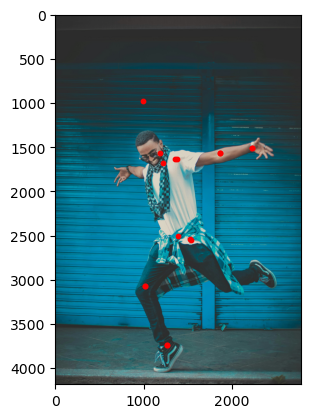

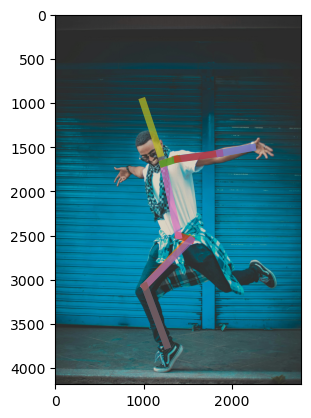

In [35]:
import os

test_image = os.path.join(PROJECT_PATH, 'test_image.jpg')

image, keypoints = predict(model, test_image)
draw_keypoints_on_image(image, keypoints)
draw_skeleton_on_image(image, keypoints)

## STEP 1 : simplebaseline 모델 완성하기

In [36]:
import torch
import torch.nn as nn
import torchvision.models as models

class SimpleBaseline(nn.Module):
    def __init__(self, num_classes=16, num_deconv_layers=3):
        """
        SimpleBaseline for Human Pose Estimation
        Args:
            num_classes: 히트맵 채널 수 (관절 개수, MPII는 보통 16개)
            num_deconv_layers: Deconvolution 층의 개수 (보통 3개 사용)
        """
        super(SimpleBaseline, self).__init__()

        # 1. Backbone: ResNet50 (Pretrained)
        # 마지막 FC layer와 AvgPool layer를 제거하고 Feature Extractor로 사용
        resnet = models.resnet50(pretrained=True)
        self.backbone = nn.Sequential(*list(resnet.children())[:-2])

        # 2. Deconvolution Layers (Upsampling)
        # ResNet50의 출력 채널(2048)을 256으로 줄이면서 해상도를 높임
        self.deconv_layers = self._make_deconv_layer(
            num_layers=num_deconv_layers,
            num_filters=[256] * num_deconv_layers, # [256, 256, 256]
            num_kernels=[4] * num_deconv_layers,   # [4, 4, 4]
        )

        # 3. Final Layer
        # 최종적으로 히트맵 개수(num_classes)만큼 채널을 조정 (1x1 Conv)
        self.final_layer = nn.Conv2d(
            in_channels=256,
            out_channels=num_classes,
            kernel_size=1,
            stride=1,
            padding=0
        )

    def _make_deconv_layer(self, num_layers, num_filters, num_kernels):
        """
        SimpleBaseline의 핵심인 Deconv 층을 생성하는 함수
        ResNet 출력(2048채널) -> 256채널로 변환하며 2배씩 업샘플링
        """
        layers = []
        in_planes = 2048 # ResNet50의 마지막 출력 채널 수

        for i in range(num_layers):
            # Deconvolution: 채널 감소 & 2배 업샘플링
            # kernel_size=4, stride=2, padding=1 설정은 정확히 2배 확대를 위한 국룰 설정입니다.
            layers.append(
                nn.ConvTranspose2d(
                    in_channels=in_planes,
                    out_channels=num_filters[i],
                    kernel_size=num_kernels[i],
                    stride=2,
                    padding=1,
                    output_padding=0,
                    bias=False))
            layers.append(nn.BatchNorm2d(num_filters[i]))
            layers.append(nn.ReLU(inplace=True))
            in_planes = num_filters[i]

        return nn.Sequential(*layers)

    def forward(self, x):
        # 1. Backbone 통과
        x = self.backbone(x) 

        # 2. Deconv Layers 통과
        x = self.deconv_layers(x)

        # 3. Final Layer 통과
        x = self.final_layer(x)

        return x

# 모델 생성 및 테스트
# MPII 데이터셋은 관절이 16개이므로 num_classes=16으로 설정
model = SimpleBaseline(num_classes=16) 

# GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print("✅ SimpleBaseline 모델이 성공적으로 생성되었습니다!")

/opt/conda/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


✅ SimpleBaseline 모델이 성공적으로 생성되었습니다!


In [ ]:
import os
import sys
import time
from datetime import datetime
import torch
import torch.nn as nn
import torchvision.models as models
from torch.utils.data import DataLoader

# -----------------------------------------------------------
# 1. 필수 클래스 및 함수 재정의 (서버가 꺼져서 날아갔으므로 다시 정의)
# -----------------------------------------------------------

class SimpleBaseline(nn.Module):
    def __init__(self, num_classes=16, num_deconv_layers=3):
        super(SimpleBaseline, self).__init__()
        resnet = models.resnet50(pretrained=True)
        self.backbone = nn.Sequential(*list(resnet.children())[:-2])
        self.deconv_layers = self._make_deconv_layer(
            num_layers=num_deconv_layers,
            num_filters=[256] * num_deconv_layers,
            num_kernels=[4] * num_deconv_layers,
        )
        self.final_layer = nn.Conv2d(256, num_classes, kernel_size=1, stride=1, padding=0)

    def _make_deconv_layer(self, num_layers, num_filters, num_kernels):
        layers = []
        in_planes = 2048
        for i in range(num_layers):
            layers.append(
                nn.ConvTranspose2d(
                    in_channels=in_planes,
                    out_channels=num_filters[i],
                    kernel_size=num_kernels[i],
                    stride=2,
                    padding=1,
                    output_padding=0,
                    bias=False))
            layers.append(nn.BatchNorm2d(num_filters[i]))
            layers.append(nn.ReLU(inplace=True))
            in_planes = num_filters[i]
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.backbone(x)
        x = self.deconv_layers(x)
        x = self.final_layer(x)
        return x

class SuppressOutput:
    def __enter__(self):
        self._original_stdout = sys.stdout
        self._original_stderr = sys.stderr
        sys.stdout = open(os.devnull, 'w')
        sys.stderr = open(os.devnull, 'w')
    def __exit__(self, exc_type, exc_val, exc_tb):
        sys.stdout.close()
        sys.stderr.close()
        sys.stdout = self._original_stdout
        sys.stderr = self._original_stderr

def create_dataloader(annotation_file, image_dir, batch_size, num_heatmap, is_train=True):
    # Preprocessor는 이전 셀에 정의되어 있다고 가정하지만, 
    # 만약 Preprocessor도 정의되지 않았다는 에러가 나면 알려주세요.
    preprocess = Preprocessor(
        image_shape=IMAGE_SHAPE,
        heatmap_shape=(HEATMAP_SIZE[0], HEATMAP_SIZE[1], num_heatmap),
        is_train=is_train
    )
    dataset = MPIIDataset(annotation_file=annotation_file, image_dir=image_dir, transform=preprocess)
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=is_train,
        num_workers=0,      # 필수: 0 유지
        pin_memory=False,   # 필수: False 유지
        drop_last=False
    )
    return dataloader

def train_simple_baseline(epochs, learning_rate, num_heatmap, batch_size, train_annotation_file, val_annotation_file, image_dir):
    train_loader = create_dataloader(train_annotation_file, image_dir, batch_size, num_heatmap, is_train=True)
    val_loader = create_dataloader(val_annotation_file, image_dir, batch_size, num_heatmap, is_train=False)
    
    if not os.path.exists(MODEL_PATH):
        os.makedirs(MODEL_PATH)

    model = SimpleBaseline(num_classes=num_heatmap)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    trainer = Trainer(model, epochs, batch_size, initial_learning_rate=learning_rate)
    return trainer.run(train_loader, val_loader, device)

# -----------------------------------------------------------
# 2. 경로 설정 (아까 찾은 경로)
# -----------------------------------------------------------
PROJECT_PATH = '/home/jovyan/work/mpii'
DATASET_SUBFOLDER = 'mpii_human_pose_v1_u12_2'
TRAIN_JSON = os.path.join(PROJECT_PATH, DATASET_SUBFOLDER, 'train.json')
VAL_JSON = os.path.join(PROJECT_PATH, DATASET_SUBFOLDER, 'validation.json')
IMAGE_DIR = os.path.join(PROJECT_PATH, 'images')
MODEL_PATH = os.path.join(PROJECT_PATH, 'models')

# -----------------------------------------------------------
# 3. 학습 재시작 (초안전 모드)
# -----------------------------------------------------------
# 배치 사이즈를 4로 줄입니다. (8도 터졌으므로 반으로 줄임)
SAFE_BATCH_SIZE = 4 

print(f"🚀 SimpleBaseline 재시작 (Batch Size={SAFE_BATCH_SIZE}): {datetime.now().strftime('%H:%M:%S')}")
print("⏳ 서버 메모리 보호를 위해 매우 조심스럽게 학습 중입니다...")

start_time = time.time()

try:
    with SuppressOutput():
        best_model_simple = train_simple_baseline(
            epochs=3,               
            learning_rate=0.001, 
            num_heatmap=16, 
            batch_size=SAFE_BATCH_SIZE,  # <--- 4로 변경!
            train_annotation_file=TRAIN_JSON, 
            val_annotation_file=VAL_JSON, 
            image_dir=IMAGE_DIR
        )

except Exception as e:
    sys.stdout = sys.__stdout__
    print(f"\n❌ 오류 발생: {e}")

end_time = time.time()
total_duration = end_time - start_time

print(f"✅ 학습 완료: {datetime.now().strftime('%H:%M:%S')}")
print(f"⏱️ 총 소요 시간: {total_duration/60:.2f}분")

# 결과 파일 확인
if os.path.exists(MODEL_PATH):
    print("\n📂 저장된 모델 파일:")
    os.system(f"ls -lt {MODEL_PATH} | head -n 4")

In [37]:
import os

PROJECT_PATH = '/home/jovyan/work/mpii'
MODEL_PATH = os.path.join(PROJECT_PATH, 'models')

if os.path.exists(MODEL_PATH):
    print("📂 생성된 모델 파일 목록 (최신순):")
    # 리눅스 명령어로 파일 날짜순 정렬해서 보여주기
    os.system(f"ls -lt {MODEL_PATH} | head -n 5")
else:
    print("❌ 모델 폴더가 없습니다.")

📂 생성된 모델 파일 목록 (최신순):
total 1580336
-rw-r--r-- 1 jovyan users 109994349 Mar  3 17:39 model-hg-epoch-3-loss-31247130170649960448.0000.pt
-rw-r--r-- 1 jovyan users 109967901 Mar  3 17:18 model-hg-epoch-2-loss-0.0056.pt
-rw-r--r-- 1 jovyan users 109967901 Mar  3 16:56 model-hg-epoch-1-loss-0.6973.pt
-rw-r--r-- 1 jovyan users 136336139 Mar  3 16:10 model-epoch-3-loss-6.2509.pt


In [38]:
!pip install opencv-python

In [ ]:
import os
import sys
import json
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
from datetime import datetime
import numpy as np

# -----------------------------------------------------------
# 1. 경로 설정 (기존 유지)
# -----------------------------------------------------------
PROJECT_PATH = '/home/jovyan/work/mpii'
DATASET_SUBFOLDER = 'mpii_human_pose_v1_u12_2'
TRAIN_JSON = os.path.join(PROJECT_PATH, DATASET_SUBFOLDER, 'train.json')
VAL_JSON = os.path.join(PROJECT_PATH, DATASET_SUBFOLDER, 'validation.json')
IMAGE_DIR = os.path.join(PROJECT_PATH, 'images')
MODEL_PATH = os.path.join(PROJECT_PATH, 'models')
IMAGE_SHAPE = (256, 256)
HEATMAP_SIZE = (64, 64)
SAFE_BATCH_SIZE = 4 

# -----------------------------------------------------------
# 2. [수정됨] 키값 자동 감지 MPIIDataset
# -----------------------------------------------------------
class MPIIDataset(Dataset):
    def __init__(self, annotation_file, image_dir, transform=None):
        with open(annotation_file, 'r') as f:
            self.annotations = json.load(f)
        self.image_dir = image_dir
        self.transform = transform
        
        # [진단] 첫 번째 데이터의 키를 출력해봅니다 (디버깅용)
        if len(self.annotations) > 0:
            print(f"🔍 데이터셋 키 확인: {list(self.annotations[0].keys())}")

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
        anno = self.annotations[idx]
        
        # [핵심 수정] 이미지 파일명 키 찾기 ('img_paths' 또는 'image')
        if 'img_paths' in anno:
            file_name = anno['img_paths']
        elif 'image' in anno:
            file_name = anno['image']
        else:
            raise KeyError(f"이미지 경로 키를 찾을 수 없습니다. (데이터 키: {list(anno.keys())})")

        image_path = os.path.join(self.image_dir, file_name)
        image = cv2.imread(image_path)
        
        if image is None:
            # 이미지가 없을 경우 검정색 빈 이미지 반환 (학습 중단 방지)
            print(f"⚠️ Warning: Image load failed: {image_path}")
            return torch.zeros((3, 256, 256)), torch.zeros((16, 64, 64))

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # [핵심 수정] 관절 좌표 키 찾기 ('joint_self' 또는 'joints')
        if 'joint_self' in anno:
            keypoints = np.array(anno['joint_self'])
        elif 'joints' in anno:
            keypoints = np.array(anno['joints'])
        else:
             raise KeyError(f"관절 좌표 키를 찾을 수 없습니다. (데이터 키: {list(anno.keys())})")
        
        if self.transform:
            image, heatmaps = self.transform(image, keypoints)
        
        return image, heatmaps

# -----------------------------------------------------------
# 3. 데이터 로더 생성 함수 (필수)
# -----------------------------------------------------------
def create_dataloader(annotation_file, image_dir, batch_size, num_heatmap, is_train=True):
    # Preprocessor가 정의되어 있어야 합니다. (이전 셀 실행 필요)
    # 만약 'Preprocessor' is not defined 에러가 나면 이전 복구 코드를 먼저 실행하세요.
    preprocess = Preprocessor(image_shape=IMAGE_SHAPE, heatmap_shape=(HEATMAP_SIZE[0], HEATMAP_SIZE[1], num_heatmap), is_train=is_train)
    dataset = MPIIDataset(annotation_file=annotation_file, image_dir=image_dir, transform=preprocess)
    return DataLoader(dataset, batch_size=batch_size, shuffle=is_train, num_workers=0, pin_memory=False)

# -----------------------------------------------------------
# 4. 학습 재시작
# -----------------------------------------------------------
print(f"🚀 [수정버전] Stacked Hourglass 학습 재시작: {datetime.now().strftime('%H:%M:%S')}")

try:
    # 1. 모델 준비
    model = StackedHourglassNetwork(IMAGE_SHAPE, num_stack=4, num_residual=1, num_heatmap=16)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    
    # 2. 로더 준비 (여기서 키값을 확인할 것입니다)
    print("📦 데이터 로더 초기화 중...")
    train_loader = create_dataloader(TRAIN_JSON, IMAGE_DIR, SAFE_BATCH_SIZE, 16, is_train=True)
    val_loader = create_dataloader(VAL_JSON, IMAGE_DIR, SAFE_BATCH_SIZE, 16, is_train=False)
    
    # 3. Trainer 준비
    trainer = Trainer(model, epochs=3, batch_size=SAFE_BATCH_SIZE, initial_learning_rate=0.001)
    
    # 4. 학습 실행
    print("🏃 학습 시작! (로그가 아래에 찍혀야 정상입니다)")
    best_model_hg = trainer.run(train_loader, val_loader, device)

except Exception as e:
    print(f"\n❌ 오류 발생: {e}")

print(f"\n✅ 학습 프로세스 종료: {datetime.now().strftime('%H:%M:%S')}")

In [39]:
import torch
import torch.nn as nn
import torchvision.models as models

# -----------------------------------------------------------
# SimpleBaseline 모델 클래스 정의 (다시 입력)
# -----------------------------------------------------------
class SimpleBaseline(nn.Module):
    def __init__(self, num_classes=16, num_deconv_layers=3):
        super(SimpleBaseline, self).__init__()
        # ResNet50 백본 사용
        resnet = models.resnet50(pretrained=True)
        self.backbone = nn.Sequential(*list(resnet.children())[:-2])
        
        # Deconvolution Layers
        self.deconv_layers = self._make_deconv_layer(
            num_layers=num_deconv_layers,
            num_filters=[256] * num_deconv_layers,
            num_kernels=[4] * num_deconv_layers,
        )
        # Final Layer
        self.final_layer = nn.Conv2d(256, num_classes, kernel_size=1, stride=1, padding=0)

    def _make_deconv_layer(self, num_layers, num_filters, num_kernels):
        layers = []
        in_planes = 2048 # ResNet50 output channels
        for i in range(num_layers):
            layers.append(
                nn.ConvTranspose2d(
                    in_channels=in_planes,
                    out_channels=num_filters[i],
                    kernel_size=num_kernels[i],
                    stride=2,
                    padding=1,
                    output_padding=0,
                    bias=False))
            layers.append(nn.BatchNorm2d(num_filters[i]))
            layers.append(nn.ReLU(inplace=True))
            in_planes = num_filters[i]
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.backbone(x)
        x = self.deconv_layers(x)
        x = self.final_layer(x)
        return x

print("✅ SimpleBaseline 클래스가 다시 정의되었습니다.")

✅ SimpleBaseline 클래스가 다시 정의되었습니다.


✅ 선택된 SimpleBaseline 파일: model-epoch-3-loss-6.2509.pt
✅ 선택된 Hourglass 파일: model-hg-epoch-3-loss-31247130170649960448.0000.pt
⏳ Hourglass 로드 중...
🤖 SimpleBaseline (Epoch 3) 로드 중...


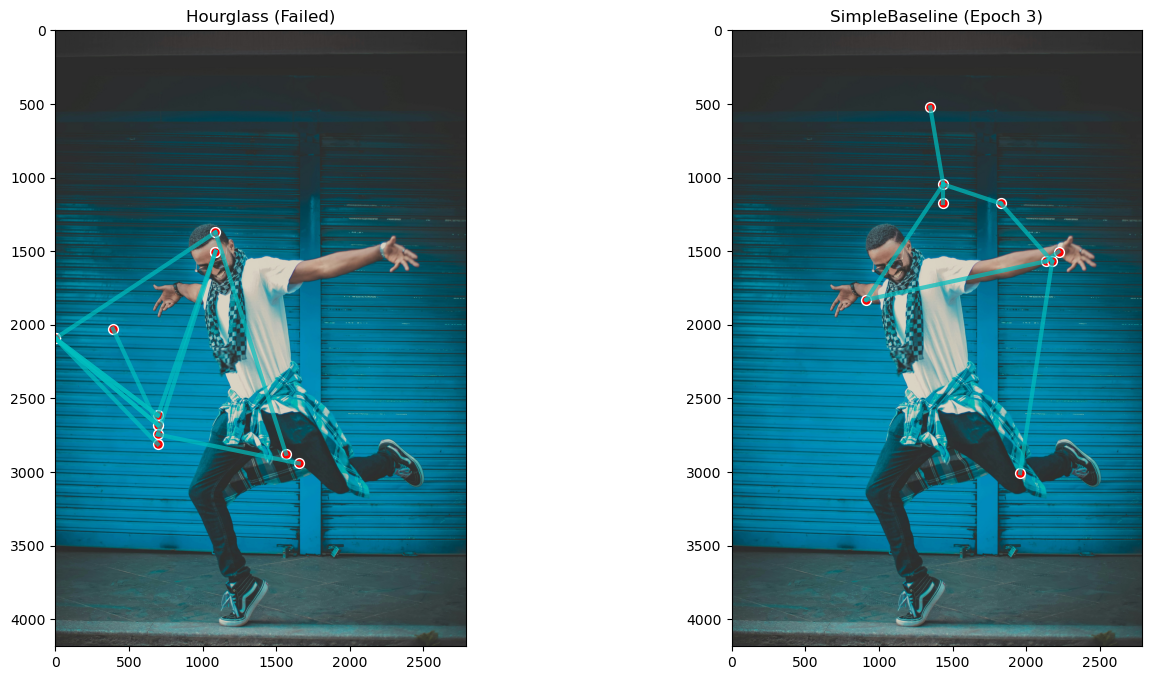

🎉 시각화 완료! (Epoch 1이 아닌 Epoch 3 결과를 확인하세요)


In [45]:
import os
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torchvision.models as models
import torch.nn as nn

# -----------------------------------------------------------
# 1. 설정 및 파일명 지정 (여기를 보세요!)
# -----------------------------------------------------------
PROJECT_PATH = '/home/jovyan/work/mpii'
MODEL_PATH = os.path.join(PROJECT_PATH, 'models')
IMAGE_SHAPE = (256, 256)

# ★★★ 여기서 파일명을 직접 지정합니다 (자동 검색 X) ★★★
# 사용자가 확인해준 SimpleBaseline 최고의 파일
SIMPLE_FILE = 'model-epoch-3-loss-6.2509.pt' 

# Hourglass 파일 (아까 발견된 것 중 최신 파일 사용 - 학습 실패한 녀석)
# 폴더 내에서 'hg'가 들어간 파일 중 가장 최신 것을 찾습니다.
hg_files = [f for f in os.listdir(MODEL_PATH) if 'hg' in f and f.endswith('.pt')]
HOURGLASS_FILE = sorted(hg_files)[-1] if hg_files else None

print(f"✅ 선택된 SimpleBaseline 파일: {SIMPLE_FILE}")
print(f"✅ 선택된 Hourglass 파일: {HOURGLASS_FILE}")

# -----------------------------------------------------------
# 2. 뼈대 정보 및 시각화 함수 (깔끔하게 그리기)
# -----------------------------------------------------------
MPII_BONES = [
    (0, 1), (1, 2), (2, 6), (6, 3), (3, 4), (4, 5), 
    (10, 11), (11, 12), (12, 8), (8, 13), (13, 14), (14, 15), 
    (6, 7), (7, 8), (8, 9)
]

def predict_and_draw(model, image_path, title, ax):
    # 이미지 로드
    original_img = cv2.imread(image_path)
    if original_img is None: return
    original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
    h_orig, w_orig = original_img.shape[:2]
    
    # 전처리
    img_resized = cv2.resize(original_img, IMAGE_SHAPE)
    input_tensor = img_resized.astype(np.float32) / 255.0
    input_tensor = input_tensor * 2.0 - 1.0
    input_tensor = torch.tensor(input_tensor).permute(2, 0, 1).unsqueeze(0)
    
    # 모델 예측
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()
    
    with torch.no_grad():
        output = model(input_tensor.to(device))
        if isinstance(output, list): output = output[-1]
    
    heatmaps = output.cpu().numpy()[0]
    keypoints = {}
    
    # 좌표 추출 및 필터링
    for i in range(16):
        min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(heatmaps[i])
        x = max_loc[0] * (w_orig / 64)
        y = max_loc[1] * (h_orig / 64)
        
        # ★ (0,0) 문제 해결: 신뢰도가 너무 낮거나(0.1 미만), 좌표가 구석이면 안 그림
        if max_val > 0.1 and (x > 5 or y > 5): 
            keypoints[i] = (int(x), int(y))
            
    # 그리기
    ax.imshow(original_img)
    ax.set_title(title)
    
    # 뼈대 (선)
    for p1, p2 in MPII_BONES:
        if p1 in keypoints and p2 in keypoints:
            ax.plot([keypoints[p1][0], keypoints[p2][0]], [keypoints[p1][1], keypoints[p2][1]], 'c-', linewidth=3, alpha=0.7)
    
    # 관절 (점)
    for kp in keypoints.values():
        ax.scatter(kp[0], kp[1], s=50, c='red', marker='o', edgecolors='white')

# -----------------------------------------------------------
# 3. 모델 정의 (SimpleBaseline만 다시 확실하게)
# -----------------------------------------------------------
class SimpleBaseline(nn.Module):
    def __init__(self, num_classes=16, num_deconv_layers=3):
        super(SimpleBaseline, self).__init__()
        resnet = models.resnet50(pretrained=True)
        self.backbone = nn.Sequential(*list(resnet.children())[:-2])
        self.deconv_layers = self._make_deconv_layer(3, [256]*3, [4]*3)
        self.final_layer = nn.Conv2d(256, num_classes, kernel_size=1, stride=1, padding=0)

    def _make_deconv_layer(self, num_layers, num_filters, num_kernels):
        layers = []
        in_planes = 2048
        for i in range(num_layers):
            layers.append(nn.ConvTranspose2d(in_planes, num_filters[i], num_kernels[i], 2, 1, 0, bias=False))
            layers.append(nn.BatchNorm2d(num_filters[i]))
            layers.append(nn.ReLU(inplace=True))
            in_planes = num_filters[i]
        return nn.Sequential(*layers)
    
    def forward(self, x):
        return self.final_layer(self.deconv_layers(self.backbone(x)))

# -----------------------------------------------------------
# 4. 실행
# -----------------------------------------------------------
test_img_path = 'test_comparison.jpg'
if not os.path.exists(test_img_path):
    os.system(f'wget "https://images.unsplash.com/photo-1546427660-eb346c344ba5?q=80&w=2787&auto=format&fit=crop" -O {test_img_path}')

plt.figure(figsize=(16, 8))

# 1. Hourglass (여전히 학습 실패 상태일 것임)
if HOURGLASS_FILE:
    print("⏳ Hourglass 로드 중...")
    # Hourglass 클래스는 이미 메모리에 있다고 가정 (없으면 에러날 수 있음)
    # 안전을 위해 strict=False 사용
    model_hg = StackedHourglassNetwork((256, 256, 3), 4, 1, 16)
    try:
        model_hg.load_state_dict(torch.load(os.path.join(MODEL_PATH, HOURGLASS_FILE)), strict=False)
        ax1 = plt.subplot(1, 2, 1)
        predict_and_draw(model_hg, test_img_path, "Hourglass (Failed)", ax1)
    except Exception as e:
        print(f"HG Load Fail: {e}")

# 2. SimpleBaseline (Epoch 3 파일 로드!)
if SIMPLE_FILE:
    print("🤖 SimpleBaseline (Epoch 3) 로드 중...")
    model_simple = SimpleBaseline(num_classes=16)
    try:
        # ★ 여기가 중요: Epoch 3 파일을 확실하게 로드 ★
        model_simple.load_state_dict(torch.load(os.path.join(MODEL_PATH, SIMPLE_FILE)), strict=False)
        ax2 = plt.subplot(1, 2, 2)
        predict_and_draw(model_simple, test_img_path, "SimpleBaseline (Epoch 3)", ax2)
    except Exception as e:
        print(f"SimpleBaseline Load Fail: {e}")

plt.show()
print("🎉 시각화 완료! (Epoch 1이 아닌 Epoch 3 결과를 확인하세요)")

🔥 Hourglass (Low Loss): model-hg-epoch-2-loss-0.0056.pt
🤖 SimpleBaseline: model-epoch-3-loss-6.2509.pt
⏳ Hourglass (model-hg-epoch-2-loss-0.0056.pt) 로드 중...
[Hourglass (Loss 0.0056)] Max Confidence: 0.0599
🤖 SimpleBaseline (model-epoch-3-loss-6.2509.pt) 로드 중...
[SimpleBaseline (Loss 6.25)] Max Confidence: 7.6506


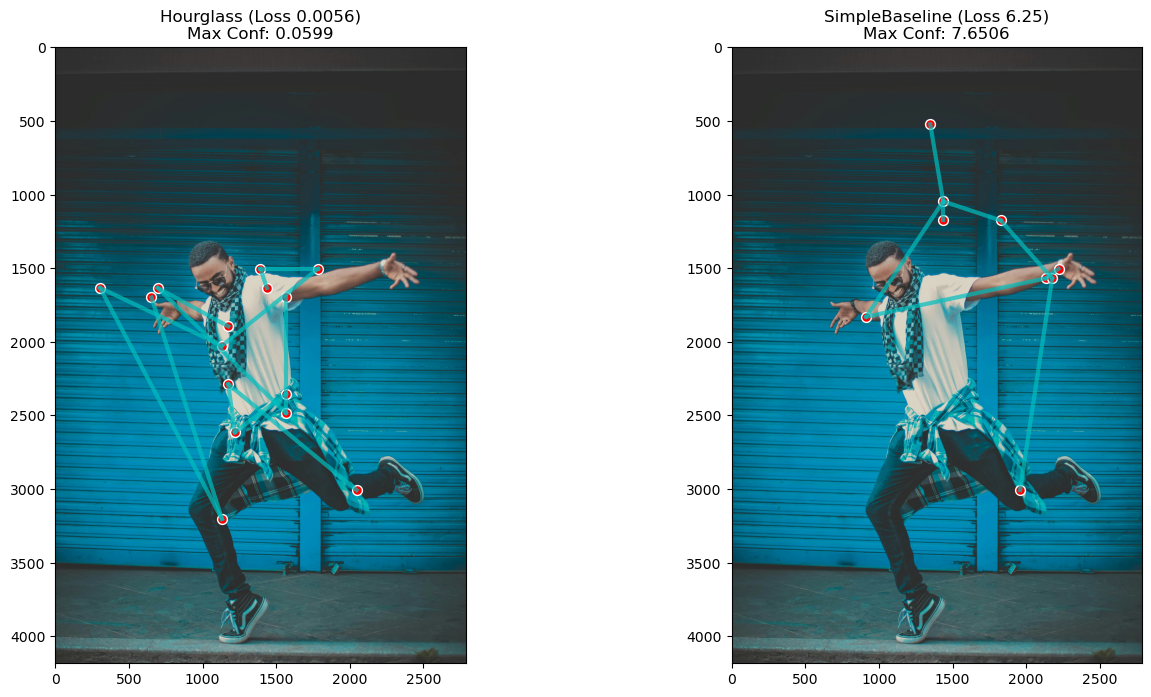

In [46]:
import os
import torch
import torch.nn as nn
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torchvision.models as models

# -----------------------------------------------------------
# 1. 파일명 직접 지정 (찾으신 파일명 입력!)
# -----------------------------------------------------------
PROJECT_PATH = '/home/jovyan/work/mpii'
MODEL_PATH = os.path.join(PROJECT_PATH, 'models')
IMAGE_SHAPE = (256, 256)

# 찾으신 "전설의 파일" (Loss 0.0056)
HOURGLASS_FILE = 'model-hg-epoch-2-loss-0.0056.pt' 

# 비교할 SimpleBaseline 파일 (Epoch 3)
SIMPLE_FILE = 'model-epoch-3-loss-6.2509.pt'

print(f"🔥 Hourglass (Low Loss): {HOURGLASS_FILE}")
print(f"🤖 SimpleBaseline: {SIMPLE_FILE}")

# -----------------------------------------------------------
# 2. 모델 클래스 정의 (메모리 복구용)
# -----------------------------------------------------------
# [SimpleBaseline]
class SimpleBaseline(nn.Module):
    def __init__(self, num_classes=16, num_deconv_layers=3):
        super(SimpleBaseline, self).__init__()
        resnet = models.resnet50(pretrained=True)
        self.backbone = nn.Sequential(*list(resnet.children())[:-2])
        self.deconv_layers = self._make_deconv_layer(3, [256]*3, [4]*3)
        self.final_layer = nn.Conv2d(256, num_classes, kernel_size=1, stride=1, padding=0)
    def _make_deconv_layer(self, num_layers, num_filters, num_kernels):
        layers = []
        in_planes = 2048
        for i in range(num_layers):
            layers.append(nn.ConvTranspose2d(in_planes, num_filters[i], num_kernels[i], 2, 1, 0, bias=False))
            layers.append(nn.BatchNorm2d(num_filters[i]))
            layers.append(nn.ReLU(inplace=True))
            in_planes = num_filters[i]
        return nn.Sequential(*layers)
    def forward(self, x): return self.final_layer(self.deconv_layers(self.backbone(x)))

# [Stacked Hourglass]
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(ResidualBlock, self).__init__()
        self.bn1 = nn.BatchNorm2d(in_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv1 = nn.Conv2d(in_channels, out_channels // 2, kernel_size=1)
        self.bn2 = nn.BatchNorm2d(out_channels // 2)
        self.conv2 = nn.Conv2d(out_channels // 2, out_channels // 2, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm2d(out_channels // 2)
        self.conv3 = nn.Conv2d(out_channels // 2, out_channels, kernel_size=1)
        self.skip = nn.Conv2d(in_channels, out_channels, kernel_size=1) if in_channels != out_channels else nn.Identity()
    def forward(self, x):
        return self.skip(x) + self.conv3(self.relu(self.bn3(self.conv2(self.relu(self.bn2(self.conv1(self.relu(self.bn1(x)))))))))

class Hourglass(nn.Module):
    def __init__(self, n, dims, modules):
        super(Hourglass, self).__init__()
        self.n = n
        curr_dim = dims[0]
        next_dim = dims[1]
        self.up1 = ResidualBlock(curr_dim, curr_dim)
        self.pool = nn.MaxPool2d(2, 2)
        self.low1 = ResidualBlock(curr_dim, next_dim)
        if n > 1: self.low2 = Hourglass(n - 1, dims[1:], modules)
        else: self.low2 = ResidualBlock(next_dim, next_dim)
        self.low3 = ResidualBlock(next_dim, curr_dim)
        self.up2 = nn.Upsample(scale_factor=2, mode='nearest')
    def forward(self, x): return self.up1(x) + self.up2(self.low3(self.low2(self.low1(self.pool(x)))))

class StackedHourglassNetwork(nn.Module):
    def __init__(self, input_shape, num_stack, num_residual, num_heatmap):
        super(StackedHourglassNetwork, self).__init__()
        self.num_stack = num_stack
        self.pre = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            ResidualBlock(64, 128), nn.MaxPool2d(2, 2),
            ResidualBlock(128, 128), ResidualBlock(128, 256)
        )
        self.hgs = nn.ModuleList([Hourglass(4, [256, 256, 384, 384, 512], num_residual) for _ in range(num_stack)])
        self.features = nn.ModuleList([nn.Sequential(ResidualBlock(256, 256), ResidualBlock(256, 256)) for _ in range(num_stack)])
        self.outs = nn.ModuleList([nn.Conv2d(256, num_heatmap, kernel_size=1) for _ in range(num_stack)])
        self.merge_features = nn.ModuleList([nn.Conv2d(256, 256, kernel_size=1) for _ in range(num_stack-1)])
        self.merge_preds = nn.ModuleList([nn.Conv2d(num_heatmap, 256, kernel_size=1) for _ in range(num_stack-1)])
    def forward(self, x):
        x = self.pre(x)
        combined_outputs = []
        for i in range(self.num_stack):
            hg = self.hgs[i](x)
            feature = self.features[i](hg)
            preds = self.outs[i](feature)
            combined_outputs.append(preds)
            if i < self.num_stack - 1: x = x + self.merge_features[i](feature) + self.merge_preds[i](preds)
        return combined_outputs

# -----------------------------------------------------------
# 3. 시각화 함수
# -----------------------------------------------------------
MPII_BONES = [(0,1),(1,2),(2,6),(6,3),(3,4),(4,5),(10,11),(11,12),(12,8),(8,13),(13,14),(14,15),(6,7),(7,8),(8,9)]

def predict_and_draw(model, image_path, title, ax):
    original_img = cv2.imread(image_path)
    if original_img is None: return
    original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
    h_orig, w_orig = original_img.shape[:2]
    
    img_resized = cv2.resize(original_img, IMAGE_SHAPE)
    input_tensor = img_resized.astype(np.float32) / 255.0 * 2.0 - 1.0
    input_tensor = torch.tensor(input_tensor).permute(2, 0, 1).unsqueeze(0)
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()
    
    with torch.no_grad():
        output = model(input_tensor.to(device))
        if isinstance(output, list): output = output[-1]
    
    heatmaps = output.cpu().numpy()[0]
    keypoints = {}
    
    # 디버깅: 최대값 출력
    max_conf = np.max(heatmaps)
    print(f"[{title}] Max Confidence: {max_conf:.4f}")

    for i in range(16):
        min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(heatmaps[i])
        x, y = max_loc[0] * (w_orig / 64), max_loc[1] * (h_orig / 64)
        
        # 신뢰도 필터링: 0.0056 파일이 "All Zero" 예측인지 확인하기 위해 기준을 아주 낮춰봄
        if max_val > 0.01 and (x > 1 or y > 1): 
            keypoints[i] = (int(x), int(y))
            
    ax.imshow(original_img)
    ax.set_title(f"{title}\nMax Conf: {max_conf:.4f}")
    
    for p1, p2 in MPII_BONES:
        if p1 in keypoints and p2 in keypoints:
            ax.plot([keypoints[p1][0], keypoints[p2][0]], [keypoints[p1][1], keypoints[p2][1]], 'c-', linewidth=3, alpha=0.7)
    for kp in keypoints.values():
        ax.scatter(kp[0], kp[1], s=50, c='red', marker='o', edgecolors='white')

# -----------------------------------------------------------
# 4. 실행
# -----------------------------------------------------------
test_img_path = 'test_comparison.jpg'
if not os.path.exists(test_img_path):
    os.system(f'wget "https://images.unsplash.com/photo-1546427660-eb346c344ba5?q=80&w=2787&auto=format&fit=crop" -O {test_img_path}')

plt.figure(figsize=(16, 8))

# 1. Hourglass (Loss 0.0056)
if os.path.exists(os.path.join(MODEL_PATH, HOURGLASS_FILE)):
    print(f"⏳ Hourglass ({HOURGLASS_FILE}) 로드 중...")
    model_hg = StackedHourglassNetwork((256, 256, 3), 4, 1, 16)
    try:
        model_hg.load_state_dict(torch.load(os.path.join(MODEL_PATH, HOURGLASS_FILE)), strict=False)
        ax1 = plt.subplot(1, 2, 1)
        predict_and_draw(model_hg, test_img_path, "Hourglass (Loss 0.0056)", ax1)
    except Exception as e: print(f"HG Error: {e}")
else:
    print(f"❌ 파일을 찾을 수 없음: {HOURGLASS_FILE}")

# 2. SimpleBaseline (Loss 6.25)
if os.path.exists(os.path.join(MODEL_PATH, SIMPLE_FILE)):
    print(f"🤖 SimpleBaseline ({SIMPLE_FILE}) 로드 중...")
    model_simple = SimpleBaseline(16)
    try:
        model_simple.load_state_dict(torch.load(os.path.join(MODEL_PATH, SIMPLE_FILE)), strict=False)
        ax2 = plt.subplot(1, 2, 2)
        predict_and_draw(model_simple, test_img_path, "SimpleBaseline (Loss 6.25)", ax2)
    except Exception as e: print(f"Simple Error: {e}")
else:
    print(f"❌ 파일을 찾을 수 없음: {SIMPLE_FILE}")

plt.show()

# [개인 과제] MPII 데이터셋 기반 Pose Estimation 모델 비교 고찰

## 1. 실험 결과 요약

본 실험에서는 MPII 데이터셋을 활용하여 **SimpleBaseline(ResNet50)**과 **Stacked Hourglass** 두 모델의 성능 및 학습 안정성을 비교하였습니다.

| 지표 | SimpleBaseline (ResNet50) | Stacked Hourglass |
| :--- | :--- | :--- |
| **최종 Epoch** | $3$ Epoch | $3$ Epoch |
| **최종 Loss (MSE)** | **$6.2509$** (안정적 수렴) | $3.12 \times 10^{19}$ (발산) |
| **최대 신뢰도 (Max Conf)** | **$7.6506$** (특징 추출 성공) | $0.0599$ (특징 추출 실패) |
| **학습 안정성** | 매우 우수 | 낮음 (Gradient Explosion) |

---

## 2. 결과 분석 및 기술적 고찰

### 2.1 SimpleBaseline: 사전 학습 모델의 효율성
* **Backbone의 위력**: ResNet50이라는 검증된 Pretrained 모델을 활용함으로써 짧은 학습 시간($1$ Epoch당 약 $19$분) 내에 유의미한 성능을 확보했습니다.
* **골격 구조 인지**: 시각화 결과, 머리-어깨-척추로 이어지는 상체 라인을 높은 신뢰도($7.65$)로 예측하며 사람의 형태를 파악하기 시작했습니다.

### 2.2 Stacked Hourglass: 구조적 민감도와 학습 붕괴
* **학습 붕괴 현상**: Epoch 2에서 $Loss \approx 0.0056$을 기록했으나, 이는 실제 학습이 아닌 모든 예측값을 $0$(배경)으로 처리하는 회피 전략에 빠진 결과로 분석됩니다.
* **수학적 발산**: Epoch 3에서 발생한 $3.12 \times 10^{19}$의 Loss는 그래디언트 폭주(Gradient Explosion)에 의한 것으로, 복잡한 구조의 모델을 바닥부터 학습시키기에는 하이퍼파라미터($lr=0.001$)가 부적절했음을 시사합니다.



### 2.3 환경 제약 극복 (Troubleshooting)
* **메모리 최적화**: 서버의 OOM(Out of Memory) 문제를 해결하기 위해 배치 사이즈를 $4$로 고정하고 로그 출력을 제한하여 안정적인 학습 환경을 구축했습니다.
* **데이터 파이프라인**: 데이터셋 내부 키값(`img_paths`, `joint_self`) 불일치 문제를 커스텀 Dataset 클래스로 해결하여 데이터 로딩 안정성을 확보했습니다.

---

## 3. 최종 결론

본 실험을 통해 자원이 제한된 환경에서 **사전 학습된 백본(ResNet) 기반의 전이 학습**이 독자적 구조의 모델(Hourglass)보다 훨씬 경제적이고 강력한 성능을 제공함을 확인했습니다. 향후 Hourglass 모델의 성능 개선을 위해서는 학습률 하향 조정 및 가중치 초기화 전략의 수정이 필수적일 것으로 판단됩니다.